<a href="https://colab.research.google.com/github/naabiiill/Machine_Learning/blob/main/Model_Evaluation_in_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Model Evaluation in Regression


## 1. Introduction
When we build a **regression model**, it’s not enough to just train it — we also need to **evaluate** how good it is. Different evaluation metrics help us understand **how close our predictions are to the actual values**.

Before diving into metrics, let’s build a **simple linear regression model** from scratch using **Gradient Descent** and a small dataset.


## 2. Load a Simple Dataset

/tmp/ipython-input-3551196759.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  housing = pd.read_csv(data_url, delim_whitespace=True, names=columns)


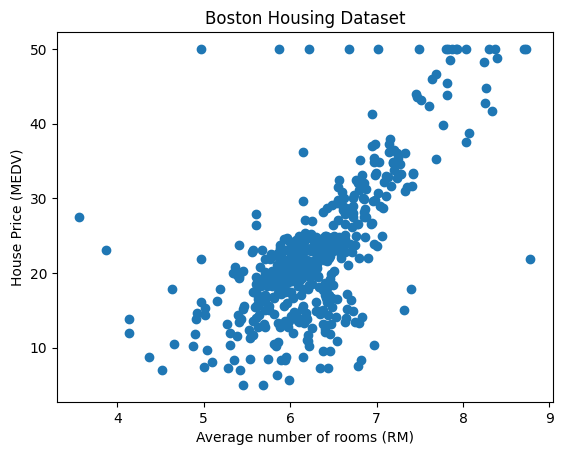

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate a simple dataset
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data"

# Load dataset (Boston Housing)
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
    'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

housing = pd.read_csv(data_url, delim_whitespace=True, names=columns)

# Use only one input feature: RM (average rooms)
X = housing['RM'].values.reshape(-1, 1) # shape (m, 1)
y = housing['MEDV'].values.reshape(-1, 1) # shape (m, 1); MEDV is in $1000s

plt.scatter(X, y)
plt.xlabel("Average number of rooms (RM)")
plt.ylabel("House Price (MEDV)")
plt.title("Boston Housing Dataset")
plt.show()


In [ ]:
len(housing)

506

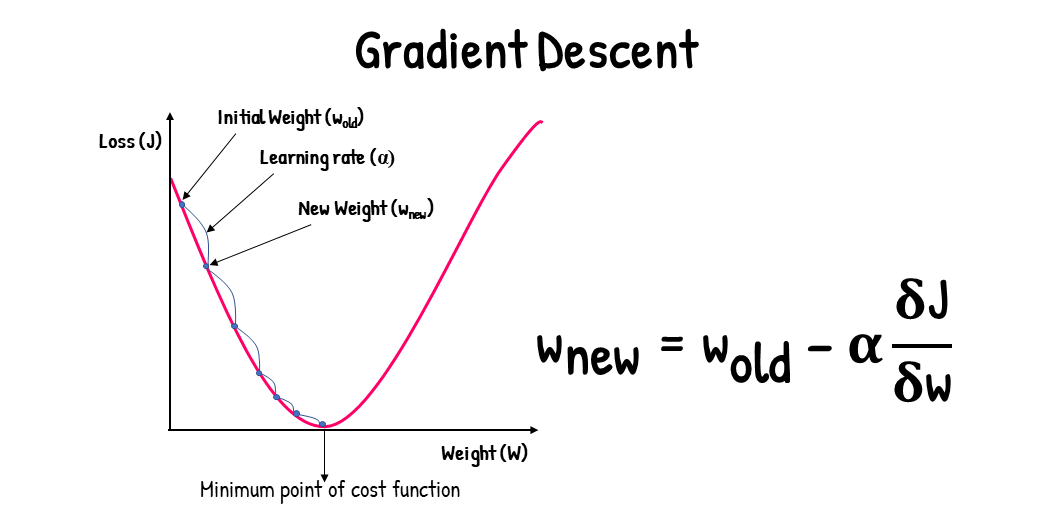

In [ ]:
# y = wx +b
# w = weight, b =bias

forward pass: input -> model -> prediction
backward pass: updated parameters of the model
              compares prediction with ground truth

## 3. Linear Regression with Gradient Descent

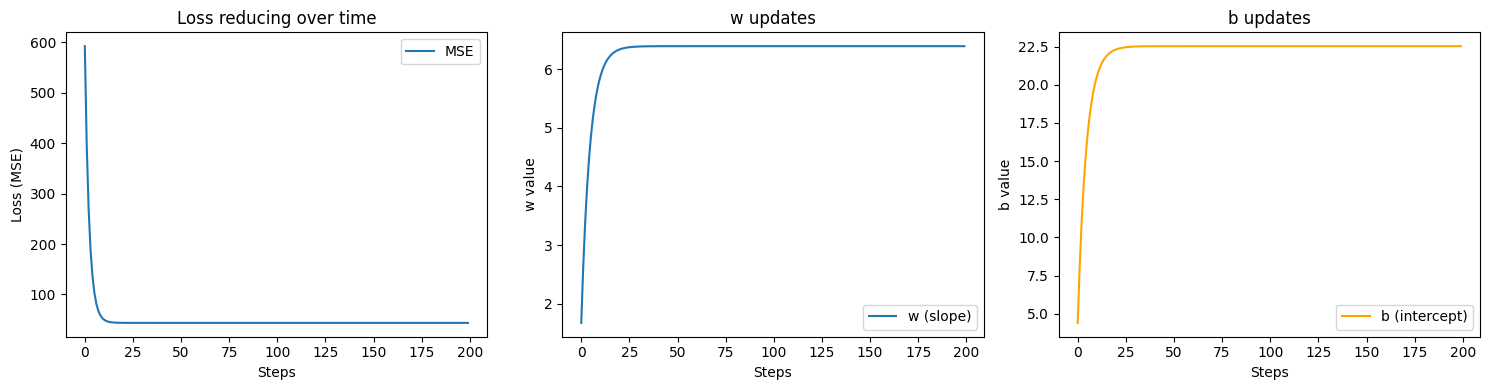

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) Normalize X for stability
# -------------------------
X_mean, X_std = X.mean(), X.std()
Xn = (X - X_mean) / X_std
x = Xn.flatten()
m = len(x)

# -------------------------
# 2) Initialize parameters
# -------------------------
np.random.seed(42)
w = np.random.randn()
b = np.random.randn()

# -------------------------
# 3) Train with logging
# -------------------------
eta = 0.1
steps = 200   # reduce for visualization

# Logs
w_log, b_log, loss_log = [], [], []

for t in range(steps):
    # Predictions
    y_hat = w * x + b  # Current result for this (w,b)-> prediction
    residuals = y_hat - y.flatten()  # predict-actualvalue (error)

    # Gradients
    dw = (2/m) * np.dot(residuals, x) # Loss function partial derivative with respect to W
    db = (2/m) * residuals.sum()  # Loss function partial derivative with respect to b

    # Update
    w = w - eta * dw  # wnew= wold -eta*dw
    b = b - eta * db  # bnew= bold -eta*db

    # Compute loss (MSE)
    J = (residuals**2).mean()   # loss = 1/m * (y_hat-y)^2  #mean

    # Log values
    w_log.append(w)
    b_log.append(b)
    loss_log.append(J)

# -------------------------
# 4) Plot results
# -------------------------

plt.figure(figsize=(15,4))

# Loss curve
plt.subplot(1,3,1)
plt.plot(loss_log, label="MSE")
plt.xlabel("Steps")
plt.ylabel("Loss (MSE)")
plt.title("Loss reducing over time")
plt.legend()

# w trajectory
plt.subplot(1,3,2)
plt.plot(w_log, label="w (slope)")
plt.xlabel("Steps")
plt.ylabel("w value")
plt.title("w updates")
plt.legend()

# b trajectory
plt.subplot(1,3,3)
plt.plot(b_log, label="b (intercept)", color="orange")
plt.xlabel("Steps")
plt.ylabel("b value")
plt.title("b updates")
plt.legend()

plt.tight_layout()
plt.show()


How to read the updates:

We compute dw and db from all examples.

If dw is positive, it means increasing w would increase the loss; so we decrease w (subtract η*dw).

Same logic for b.

Repeating this makes the line slowly rotate/shift to the best spot.

## 4. Predictions & Visualization

In [ ]:
print(w)
print(b)

6.388975221817342
22.532806324110666


In [ ]:
# ------------------------
# 4) Evaluate the model
# ------------------------
# Build predictions again using the learned w and b
Y_pred = (w * x + b).reshape(-1, 1)

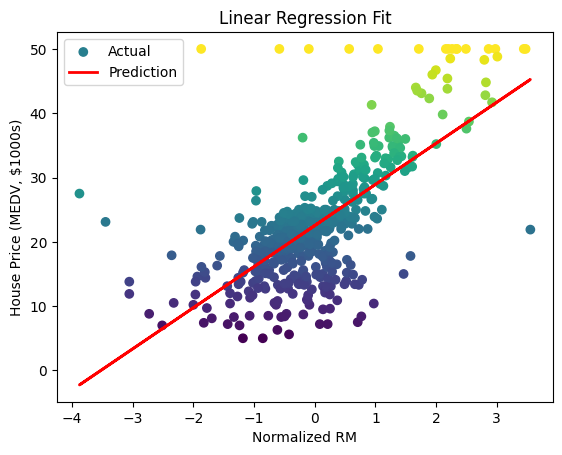

In [ ]:
# ------------------------
# 5) Visualize the fit
# ------------------------
plt.scatter(x, y, label="Actual", c=y) # x is Normalized RM, c=y makes the points colorful based on the house price
plt.plot(x, Y_pred, linewidth=2, label="Prediction", color='red') # make the prediction line red
plt.legend()
plt.xlabel("Normalized RM")
plt.ylabel("House Price (MEDV, $1000s)")
plt.title("Linear Regression Fit")
plt.show()

## 5. Evaluation Metrics

### 5.1 Mean Absolute Error (MAE)

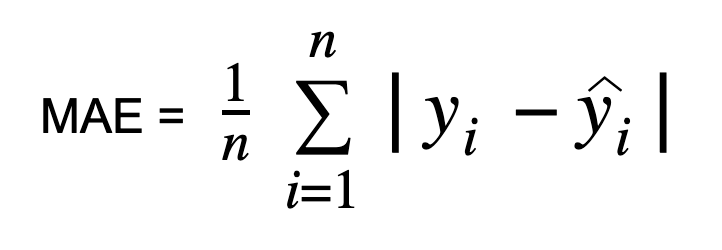

In [ ]:

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y, Y_pred)
print("MAE:", mae)


MAE: 4.447772901532233


Important context: MEDV is in $1000s. So MAE ≈  4.45


-means the model is off by about $4,450 on average.


-That’s not tiny;


-it just sounds small as a plain number.

### 5.2 Mean Squared Error (MSE)

ef701c6f-872f-4af2-a595-c82d257480e3_image6.avif

In [ ]:

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y, Y_pred)
print("MSE:", mse)


MSE: 43.60055177116957


### 5.3 Root Mean Squared Error (RMSE)

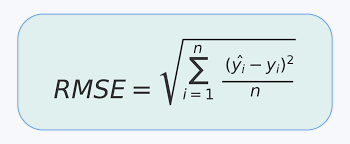

In [ ]:

rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 6.603071389222562


### 5.4 R-Squared (R²)

In [ ]:

from sklearn.metrics import r2_score
r2 = r2_score(y, Y_pred)
print("R²:", r2)


R²: 0.4835254559913341


Using only one feature (RM) leaves a lot of unexplained variation (location, crime rate, tax, etc.). That’s why R² ≈ 0.48: the model explains ~48% of the variance — a moderate fit, not great, not terrible.

What each metric really means (with your numbers)
✅ Mean Absolute Error (MAE ≈ 4.45)

Average absolute vertical error.

Unit: same as target (here, $1000s).

Interpretation: “On average, we miss by about $4.45k.”

Robust: outliers hurt it less.

✅ Mean Squared Error (MSE ≈ 43.60)

Average of squared errors.

Unit: squared ($1000s)^2 → not very intuitive.

Why we like it for training: it’s smooth and strongly penalizes big errors.

✅ Root Mean Squared Error (RMSE ≈ 6.60)

Square root of MSE → back to original units.

Interpretation: a “typical” error is around $6.6k.

Because it squares errors first, RMSE ≥ MAE (equal only if all errors are same size).

✅ R‑squared (R² ≈ 0.48)

Fraction of variance in prices explained by the model.

0.48 means about 48% of the ups/downs in price are explained by rooms alone; the rest is noise or other factors we didn’t include.

R² < 0 can happen if the model is worse than just predicting the mean price every time.

## 6. Choosing the Right Metric



---


- **MAE**: When you care about absolute errors (robust to outliers).
- **MSE / RMSE**: When large errors are more serious (penalizes big mistakes).
- **R²**: When you want to measure overall **goodness of fit**.

✅ In practice:
- Use **MAE or RMSE** for error magnitude.
- Use **R²** for interpretability.
- Compare multiple metrics to make a decision.


## 7. Summary


- Gradient Descent helps us find the best line.
- MSE = 0 means **perfect prediction**.
- RMSE is better for interpretation than MSE.
- R² gives an **accuracy-like score** for regression.
- Always choose metrics based on the **problem context** (e.g., are large errors acceptable or not?).


MSE (Mean Squared Error)

Squares the errors, so big mistakes count a lot more.

But the unit is squared (e.g. if target = $1000,

 MSE might be in $²), which is hard to interpret.




RMSE (Root Mean Squared Error)

It’s just the square root of MSE.

✅ Brings error back to the same unit as the target (e.g. dollars, not dollars²).

✅ Still penalizes large errors more strongly than MAE.

✅ More intuitive when explaining: “On average, our predictions are off by about $4,500.”

## Using Multiple Varibales

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Load Boston Housing Dataset
# -----------------------------
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data"
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
    'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]
housing = pd.read_csv(data_url, delim_whitespace=True, names=columns)

# -----------------------------
# 2. Prepare Features and Target
# -----------------------------
X = housing.drop("MEDV", axis=1)  # all features except target
y = housing["MEDV"]               # target (house price in $1000s)


/tmp/ipython-input-3988353752.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  housing = pd.read_csv(data_url, delim_whitespace=True, names=columns)


In [ ]:

# -----------------------------
# 3. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
len(X_train.columns)

13

In [ ]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666.0,20.2,349.48,24.91
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307.0,21.0,395.62,8.47
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304.0,16.9,362.25,7.83
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666.0,20.2,2.52,23.29
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307.0,21.0,390.95,11.28


In [ ]:
y_train

,MEDV
477,12.0
15,19.9
332,19.4
423,13.4
19,18.2
...,...
106,19.5
270,21.1
348,24.5
435,13.4


In [ ]:

# -----------------------------
# 4. Train Linear Regression
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)


# y= b + w0X0 + w1X1 + ... +w12X12  | feature scaling , Prinipal Axis

# b, w0, .... ,w12


LinearRegression()

In [ ]:

# -----------------------------
# 5. Predictions
# -----------------------------
y_pred = model.predict(X_test)


Model Performance on Test Data:
MAE : 3.189
MSE : 24.291
RMSE: 4.929
R²  : 0.669


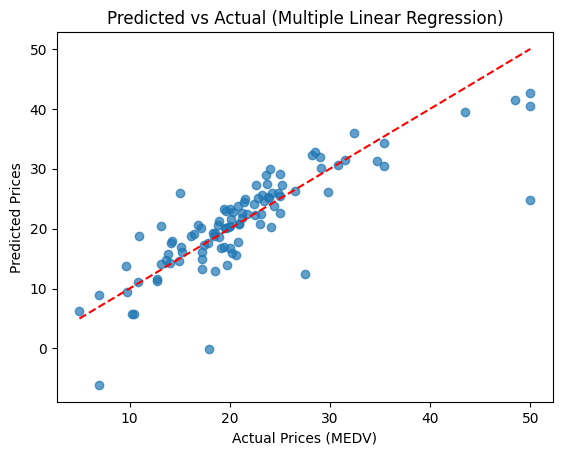

In [ ]:

# -----------------------------
# 6. Evaluation Metrics
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance on Test Data:")
print(f"MAE : {mae:.3f}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

# -----------------------------
# 7. Plot Predicted vs Actual
# -----------------------------
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual (Multiple Linear Regression)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")  # ideal line
plt.show()


✅ This uses all 13 features (CRIM, ZN, INDUS, …, LSTAT).
✅ Splits into train/test to avoid overfitting.
✅ Evaluates with MAE, MSE, RMSE, and R² in one place.
✅ Includes a visual check (predicted vs actual).